# Setting

## Library

In [72]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [73]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [74]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [75]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [76]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [77]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [78]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [79]:
logtxt = ""

In [80]:
# Set experiment configs
test_name = "Rubin_7DT_LightGBM_Fine_Tune"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 5
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [81]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [82]:
path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_rubin_7dt40.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [ ]:
columns_to_use = list(data_dtype_dict.keys())

In [83]:
import yaml
path_feature_config = os.path.join(CONFIG, "feature.yaml")

with open(path_feature_config, "r") as f:
    feature_config = yaml.safe_load(f)

feature_key = "Rubin+7DT_40"
colors = feature_config[feature_key]['color']

In [84]:
columns_to_use = list(data_dtype_dict.keys())
for feature in colors:
    if feature not in columns_to_use:
        columns_to_use.append(feature)

In [85]:
data = pd.read_csv(
    path_data,
    engine='c', 
    usecols=columns_to_use,
    # dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)

uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


KeyError: 'class'

- Training and Test Data

In [92]:
# - Split features/target
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)

# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# - Label encode class for ML
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

# Tets\\sts
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

import lightgbm as lgb
# LightGBM ???? Dataset ????
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)


Balanced: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'SLSN' 'TDE']


In [93]:
del data

# Fine Tuning

In [31]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
import optuna
from lightgbm import LGBMClassifier

def objective(trial):
	params = {
		'num_leaves': trial.suggest_int('num_leaves', 20, 37),
		'n_estimators': trial.suggest_int('n_estimators', 60, 100),
		'min_child_weight': trial.suggest_int('min_child_weight', 15, 30),
		'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
		'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
		'random_state': 42,
		'force_row_wise': True,
		'verbose': -1,
		'num_threads': n_jobs,
		# 'device': 'gpu',
	}
	#
	callbacks = [
		lgb.early_stopping(stopping_rounds=30),
		]
	#
	model = LGBMClassifier(**params)
	model.fit(
		X_train, y_train,
		#
		eval_set=[(X_test, y_test)],
		eval_metric='multi_logloss',
		callbacks=callbacks,
		)
	y_pred = model.predict(X_test)
	return f1_score(y_test, y_pred, average='macro')

In [32]:
number_of_trials = 100

t0 = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=number_of_trials)
delt = time.time() - t0
print(f"It takes {delt/60:.1f} min")
print(f"Best Value = {study.best_value}, Best Parameters = {study.best_params}")
print("Best trial:")
trial = study.best_trial

print("Value: ", trial.value)
print("Params: ")
for key, value in trial.params.items():
    print(f"{key}: {value}")

[I 2025-05-30 09:49:24,129] A new study created in memory with name: no-name-128838ef-2141-4392-adfb-6d02076254ea


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[28]	valid_0's multi_logloss: 0.890995


[I 2025-05-30 09:55:26,552] Trial 0 finished with value: 0.7549644879951702 and parameters: {'num_leaves': 35, 'n_estimators': 94, 'min_child_weight': 30, 'learning_rate': 0.12113199721341024, 'colsample_bytree': 0.9473432967943751}. Best is trial 0 with value: 0.7549644879951702.


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[29]	valid_0's multi_logloss: 0.884048


[I 2025-05-30 10:01:07,035] Trial 1 finished with value: 0.7583312775941572 and parameters: {'num_leaves': 36, 'n_estimators': 64, 'min_child_weight': 24, 'learning_rate': 0.13131832318341224, 'colsample_bytree': 0.8953058867928778}. Best is trial 1 with value: 0.7583312775941572.


...

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[57]	valid_0's multi_logloss: 0.873177


[I 2025-05-30 18:25:08,344] Trial 98 finished with value: 0.7585346657559274 and parameters: {'num_leaves': 36, 'n_estimators': 68, 'min_child_weight': 29, 'learning_rate': 0.06153682689409192, 'colsample_bytree': 0.917766860466615}. Best is trial 88 with value: 0.7702334782948705.


Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[54]	valid_0's multi_logloss: 0.850293


[I 2025-05-30 18:30:50,999] Trial 99 finished with value: 0.7645417590099977 and parameters: {'num_leaves': 36, 'n_estimators': 74, 'min_child_weight': 28, 'learning_rate': 0.05452749572752212, 'colsample_bytree': 0.7001961899786137}. Best is trial 88 with value: 0.7702334782948705.


It takes 521.4 min
Best Value = 0.7702334782948705, Best Parameters = {'num_leaves': 34, 'n_estimators': 73, 'min_child_weight': 29, 'learning_rate': 0.06561720240661661, 'colsample_bytree': 0.7285126435030206}
Best trial:
Value:  0.7702334782948705
Params: 
num_leaves: 34
n_estimators: 73
min_child_weight: 29
learning_rate: 0.06561720240661661
colsample_bytree: 0.7285126435030206


In [33]:
from optuna.visualization import plot_optimization_history, plot_param_importances
import hiplot as hip

plot_optimization_history(study)
data = [dict(trial.params, value=trial.value) for trial in study.trials]
hip.Experiment.from_iterable(data).display()

<IPython.core.display.Javascript object>

In [34]:
best_params = trial.params
best_params['random_state'] = 42
best_params['num_threads'] = n_jobs
#
import yaml
with open(f"{path_save}/best_params.yaml", "w") as f:
    yaml.dump(best_params, f, default_flow_style=False)
best_params

{'num_leaves': 34,
 'n_estimators': 73,
 'min_child_weight': 29,
 'learning_rate': 0.06561720240661661,
 'colsample_bytree': 0.7285126435030206,
 'random_state': 42,
 'num_threads': 5}

In [35]:
best_model = LGBMClassifier(**best_params)
best_model.fit(
    X_train, y_train,
    )
y_pred = best_model.predict(X_test)
# best_model.save_model(f"{path_save}/best_lightgbm_model.txt")

In [38]:
import joblib  # for XGBoost and LightGBM

# # ---------------------
# # CatBoost 저장
# # ---------------------
# cat_model.save_model(os.path.join(path_save, "best_catboost_model.txt"))

# # ---------------------
# # XGBoost 저장
# # ---------------------
# xgb_model.save_model(os.path.join(path_save, "best_xgboost_model.json"))  # .json preferred over .txt

# # ---------------------
# # LightGBM 저장
# # ---------------------
joblib.dump(best_model, os.path.join(path_save, "best_lightgbm_model.pkl"))

['/home/gpaek/SED-Classifier/notebook/../model/Rubin_7DT_LightGBM_Fine_Tune/best_lightgbm_model.pkl']

In [62]:

from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# 2. accuracy는 scalar → 딕셔너리로 따로 저장
acc_value = report_dict.pop("accuracy")

# 3. DataFrame으로 변환
report_df = pd.DataFrame(report_dict).T  # class별 성능 포함

# 4. accuracy row 추가 (f1-score 칸만 채움)
report_df.loc["accuracy"] = [None, None, acc_value, report_df["support"].sum()]


report_df

,precision,recall,f1-score,support
AGN,0.923907,0.746343,0.825686,6426.0
CV,0.806337,0.876854,0.840118,6472.0
II,0.768317,0.880351,0.820527,6611.0
Ia,0.803726,0.904411,0.851101,5963.0
Ibc,0.810511,0.670175,0.733693,5891.0
LBV,0.726295,0.659720,0.691409,6142.0
M dwarf,0.836323,0.980289,0.902601,761.0
Nova,0.623163,0.473027,0.537814,6006.0
SLSN,0.907696,0.754172,0.823843,5333.0
TDE,0.573585,0.878443,0.694011,5191.0


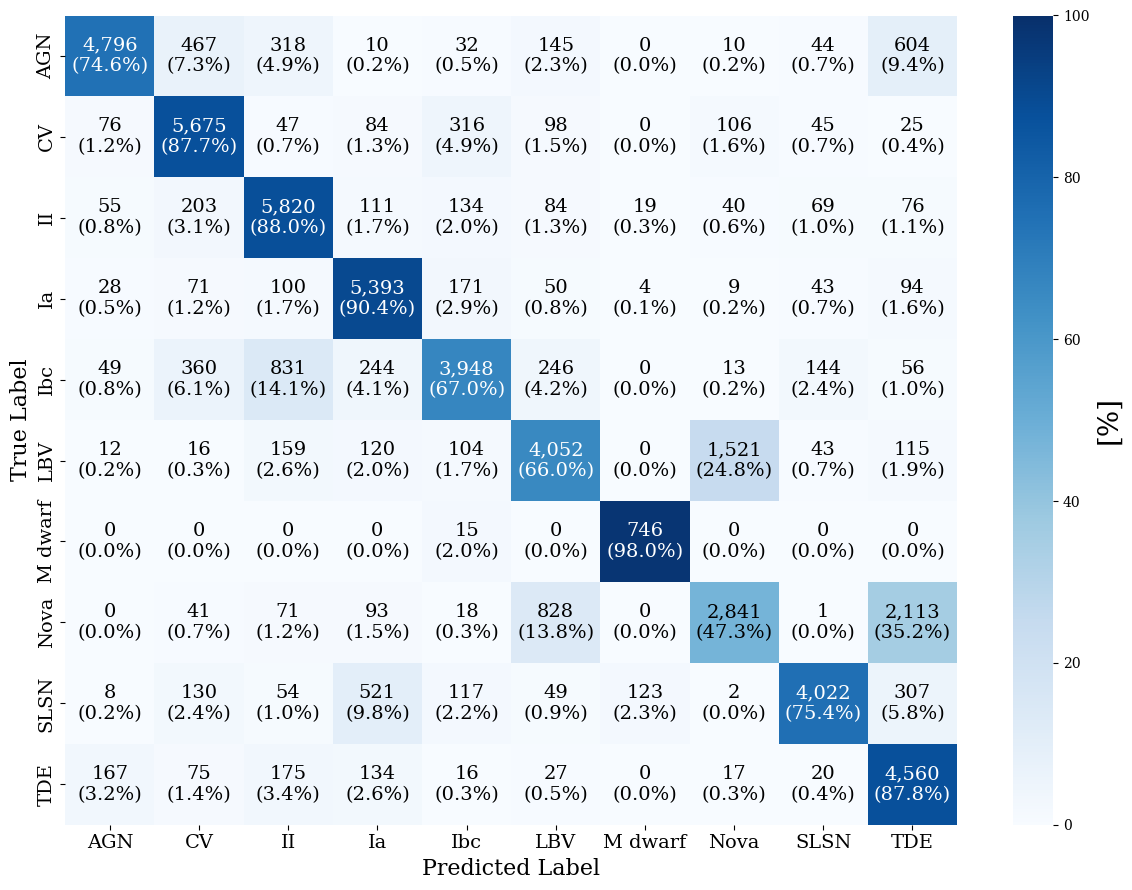

In [70]:
def plot_confusion_matrix():
    import seaborn as sns
    cm = confusion_matrix(y_test, y_pred)
    labels = label_encoder.classes_
    cm_percent = (cm / cm.sum(axis=1, keepdims=True)) * 100
    n_rows, n_cols = cm.shape
    combined_matrix = np.empty_like(cm, dtype=object)
    for i in range(n_rows):
        for j in range(n_cols):
            n = cm[i, j]
            p = cm_percent[i, j]
            combined_matrix[i, j] = f"{n:,}\n({p:.1f}%)"
    plt.figure(figsize=(12, 9))
    ax = sns.heatmap(cm_percent, annot=False, fmt="", cmap="Blues",
                        xticklabels=labels, yticklabels=labels,
                        cbar_kws={'label': '[%]'}, vmin=0, vmax=100)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.title(__class__.__name__.replace("Experiment", ""))
    plt.tight_layout()
    thresh = 50
    for i in range(n_rows):
        for j in range(n_cols):
            value = cm_percent[i, j]
            text_color = "white" if value > thresh else "black"
            ax.text(j+0.5, i+0.5, combined_matrix[i, j], ha='center', va='center', color=text_color, fontsize=14)
    # plt.savefig(os.path.join(path_save, f"{__class__.__name__.lower()}_confusion_matrix.png"))

plot_confusion_matrix()

plt.savefig(os.path.join(path_save, 'confusion_matrix.png'))

In [89]:
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
df_cm

df_cm.to_csv(os.path.join(path_save, 'confusion_matrix.csv'))

In [95]:
import os
import pandas as pd
import joblib
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report
from lightgbm import LGBMClassifier  # 예시로 LGBM 사용

# 설정
class_labels = label_encoder.classes_
groups = uids
gkf = GroupKFold(n_splits=5)

cv_macro_f1_scores = []
cv_per_class_f1_scores = []

# 저장 경로 생성
os.makedirs(path_save, exist_ok=True)

# Perform Grouped K-Fold Cross-Validation
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=groups)):

    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y_encoded[train_idx], y_encoded[val_idx]

    model_cv = LGBMClassifier(**best_params)
    model_cv.fit(
        X_train_cv, y_train_cv,
        eval_set=[(X_val_cv, y_val_cv)],
        # verbose=False
    )

    y_pred = model_cv.predict(X_val_cv)

    # === 1. Macro F1 저장 ===
    macro_f1 = f1_score(y_val_cv, y_pred, average='macro')
    cv_macro_f1_scores.append({'fold': fold, 'f1_macro': macro_f1})

    # === 2. Per-class F1 저장 ===
    report = classification_report(y_val_cv, y_pred, output_dict=True, zero_division=0)
    per_class_f1 = {label: report[str(i)]['f1-score'] for i, label in enumerate(class_labels)}
    per_class_f1['fold'] = fold
    cv_per_class_f1_scores.append(per_class_f1)

    # === 3. 모델 저장 ===
    model_path = os.path.join(path_save, f"model_fold{fold}.pkl")
    joblib.dump(model_cv, model_path)

    # === 4. 리포트 출력 ===
    print(f"[Fold {fold}] f1_macro = {macro_f1:.4f}")

# === 5. 최종 결과 저장 ===
macro_f1_df = pd.DataFrame(cv_macro_f1_scores)
per_class_f1_df = pd.DataFrame(cv_per_class_f1_scores)

macro_f1_df.to_csv(os.path.join(path_save, "cv_macro_f1_scores.csv"), index=False)
per_class_f1_df.to_csv(os.path.join(path_save, "cv_per_class_f1_scores.csv"), index=False)


[Fold 0] f1_macro = 0.7421
[Fold 1] f1_macro = 0.8070
[Fold 2] f1_macro = 0.7195
[Fold 3] f1_macro = 0.7051
[Fold 4] f1_macro = 0.7335


: 